In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

%matplotlib inline

In [8]:
df = pd.read_csv("../data/updated/upgraded_customer_retention.csv")

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn,customer_lifetime_value,revenue_tier,support_frustration_score,service_adoption_score,billing_risk_score,engagement_score,high_value_churn_flag,churn_risk_segment
0,7590-VHVEG,Female,0,Yes,No,1,0,No phone service,DSL,0,1,0,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No,29.85,Bronze,0,1,6,5.5,0,Medium Risk
1,5575-GNVDE,Male,0,No,No,34,1,No,DSL,1,0,1,0,0,0,One year,No,Mailed check,56.95,1889.50,0,0,No,1936.30,Silver,0,3,0,32.0,0,Low Risk
2,3668-QPYBK,Male,0,No,No,2,1,No,DSL,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes,107.70,Bronze,0,3,4,16.0,0,Medium Risk
3,7795-CFOCW,Male,0,No,No,45,0,No phone service,DSL,1,0,1,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No,1903.50,Silver,6,3,0,25.5,0,Medium Risk
4,9237-HQITU,Female,0,No,No,2,1,No,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes,141.40,Bronze,0,1,6,6.0,0,Medium Risk


In [11]:
df.shape

(7043, 31)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   str    
 1   gender                     7043 non-null   str    
 2   SeniorCitizen              7043 non-null   int64  
 3   Partner                    7043 non-null   str    
 4   Dependents                 7043 non-null   str    
 5   tenure                     7043 non-null   int64  
 6   PhoneService               7043 non-null   int64  
 7   MultipleLines              7043 non-null   str    
 8   InternetService            7043 non-null   str    
 9   OnlineSecurity             7043 non-null   int64  
 10  OnlineBackup               7043 non-null   int64  
 11  DeviceProtection           7043 non-null   int64  
 12  TechSupport                7043 non-null   int64  
 13  StreamingTV                7043 non-null   int64  
 14  Str

In [13]:
df.describe()

,SeniorCitizen,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,customer_lifetime_value,support_frustration_score,service_adoption_score,billing_risk_score,engagement_score,high_value_churn_flag
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,0.903166,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,64.761692,2281.916928,0.515689,0.419566,2279.581350,1.354820,2.941076,2.914383,28.181315,0.048985
std,0.368612,24.559481,0.295752,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,30.090047,2265.270398,1.275299,1.250117,2264.729447,2.797591,1.843899,2.176838,18.226655,0.215852
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.500000,0.000000
25%,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,402.225000,0.000000,0.000000,394.000000,0.000000,1.000000,1.000000,13.000000,0.000000
50%,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.350000,1397.475000,0.000000,0.000000,1393.600000,0.000000,3.000000,3.000000,25.000000,0.000000
75%,0.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,0.000000,0.000000,3786.100000,2.000000,4.000000,5.000000,40.500000,0.000000
max,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,5.000000,9.000000,8550.000000,19.000000,7.000000,6.000000,71.000000,1.000000


In [14]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing

customerID                   0
gender                       0
SeniorCitizen                0
Partner                      0
Dependents                   0
tenure                       0
PhoneService                 0
MultipleLines                0
InternetService              0
OnlineSecurity               0
OnlineBackup                 0
DeviceProtection             0
TechSupport                  0
StreamingTV                  0
StreamingMovies              0
Contract                     0
PaperlessBilling             0
PaymentMethod                0
MonthlyCharges               0
TotalCharges                 0
numAdminTickets              0
numTechTickets               0
Churn                        0
customer_lifetime_value      0
revenue_tier                 0
support_frustration_score    0
service_adoption_score       0
billing_risk_score           0
engagement_score             0
high_value_churn_flag        0
churn_risk_segment           0
dtype: int64

In [15]:
df["customerID"].duplicated().sum()

np.int64(0)

In [16]:
df.dtypes


customerID                       str
gender                           str
SeniorCitizen                  int64
Partner                          str
Dependents                       str
tenure                         int64
PhoneService                   int64
MultipleLines                    str
InternetService                  str
OnlineSecurity                 int64
OnlineBackup                   int64
DeviceProtection               int64
TechSupport                    int64
StreamingTV                    int64
StreamingMovies                int64
Contract                         str
PaperlessBilling                 str
PaymentMethod                    str
MonthlyCharges               float64
TotalCharges                 float64
numAdminTickets                int64
numTechTickets                 int64
Churn                            str
customer_lifetime_value      float64
revenue_tier                     str
support_frustration_score      int64
service_adoption_score         int64
b

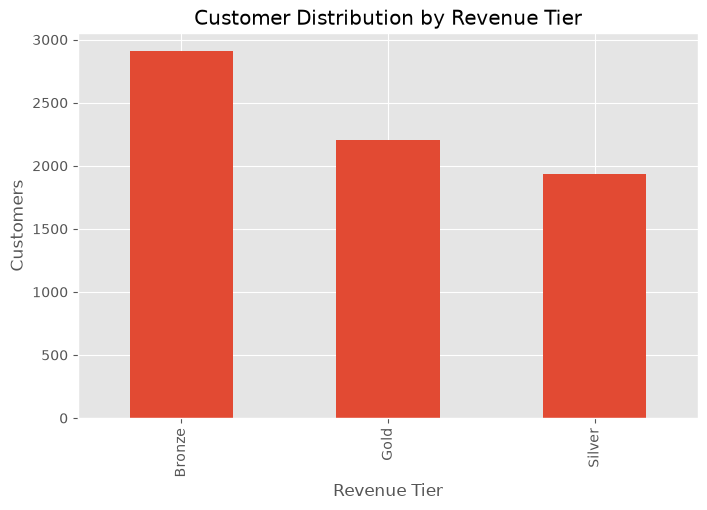

In [ ]:
#customer revenue tier
plt.figure(figsize=(8,5))

df["revenue_tier"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Revenue Tier")

plt.xlabel("Revenue Tier")

plt.ylabel("Customers")

plt.show()

# Most customers belong to the Bronze segment, indicating the business relies on a large base of lower-value customers.

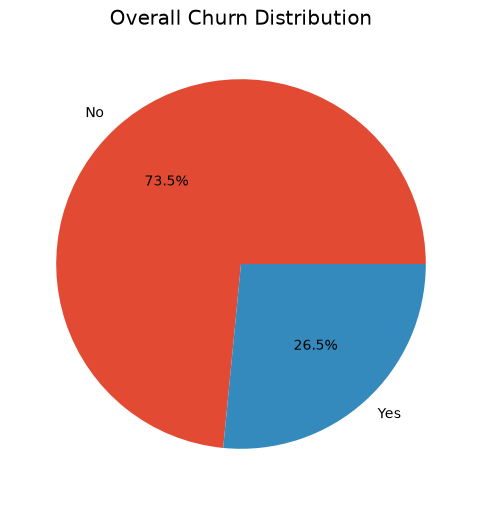

In [ ]:
#churn distribution
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Overall Churn Distribution")

plt.show()

#Approximately 26.5% customers churned.

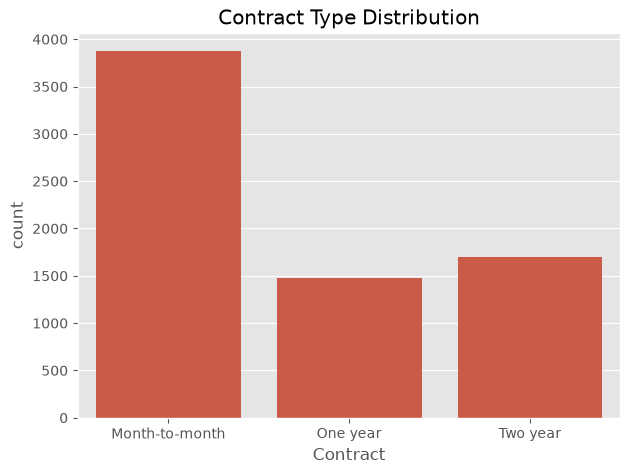

In [21]:
#contract distribution
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Contract"
)

plt.title("Contract Type Distribution")

plt.show()

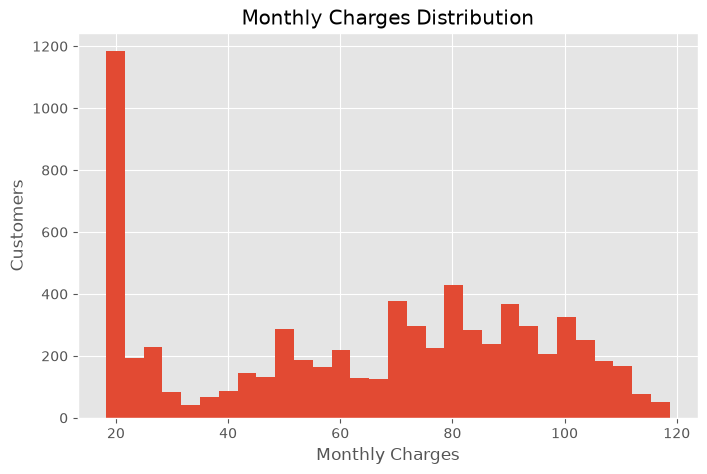

In [22]:
#monthly charges distribution
plt.figure(figsize=(8,5))

plt.hist(
    df["MonthlyCharges"],
    bins=30
)

plt.xlabel("Monthly Charges")

plt.ylabel("Customers")

plt.title("Monthly Charges Distribution")

plt.show()

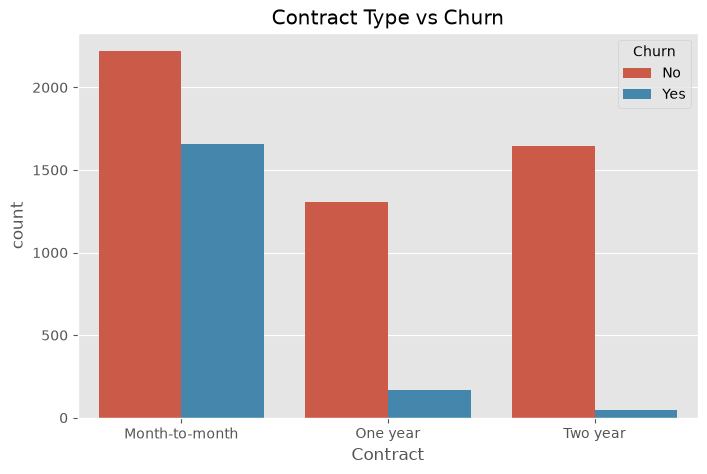

In [ ]:
#contract vs churn
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")

plt.show()

# Month-to-month customers churn far more frequently than customers on yearly contracts.

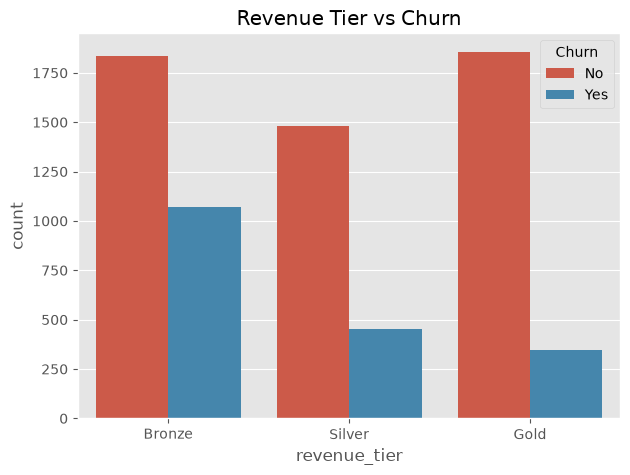

In [24]:
#revenue tier vs churn
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="revenue_tier",
    hue="Churn"
)

plt.title("Revenue Tier vs Churn")

plt.show()

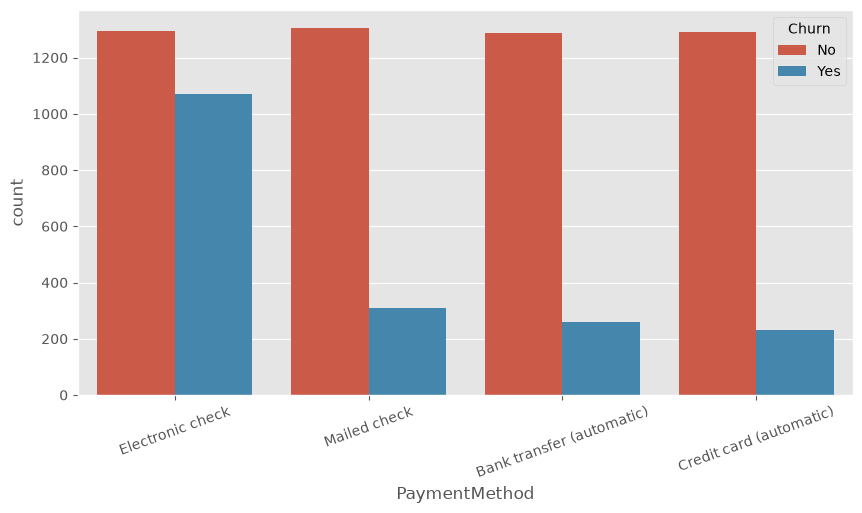

In [25]:
#payment method vs churn
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=20)

plt.show()

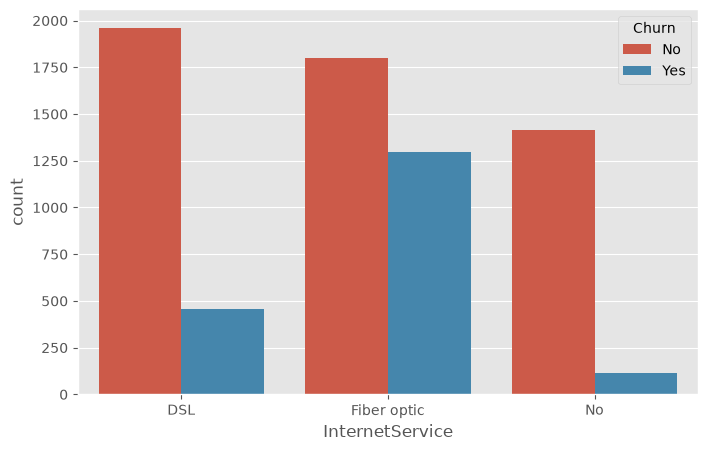

In [26]:
#internect service vs churn
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.show()

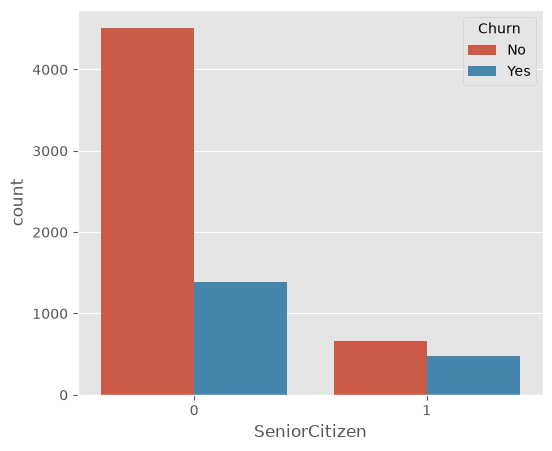

In [27]:
#senior citizen vs churn
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.show()

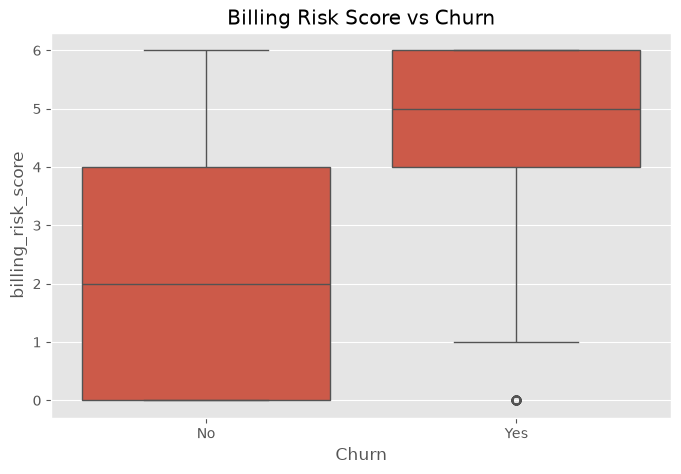

In [ ]:
#billing risk score
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="billing_risk_score"
)

plt.title("Billing Risk Score vs Churn")

plt.show()

#High billing risk customers churn more.

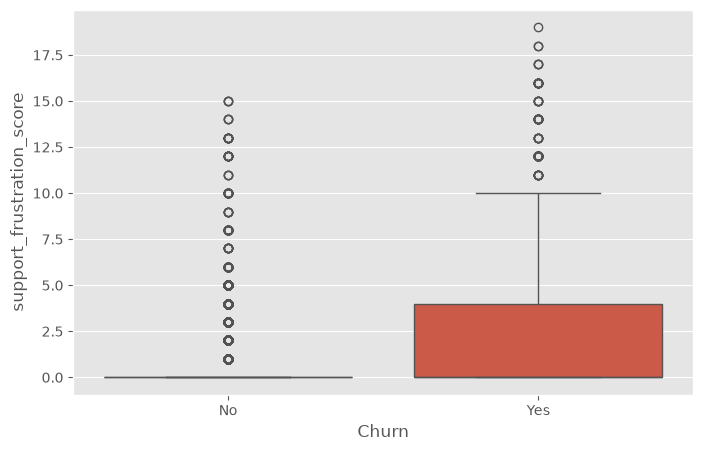

In [29]:
#support frustration churn
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="support_frustration_score"
)

plt.show()

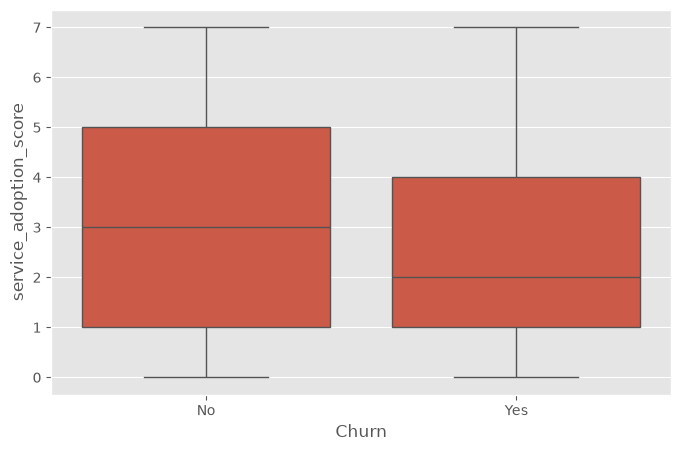

In [30]:
#service adoption churn
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="service_adoption_score"
)

plt.show()

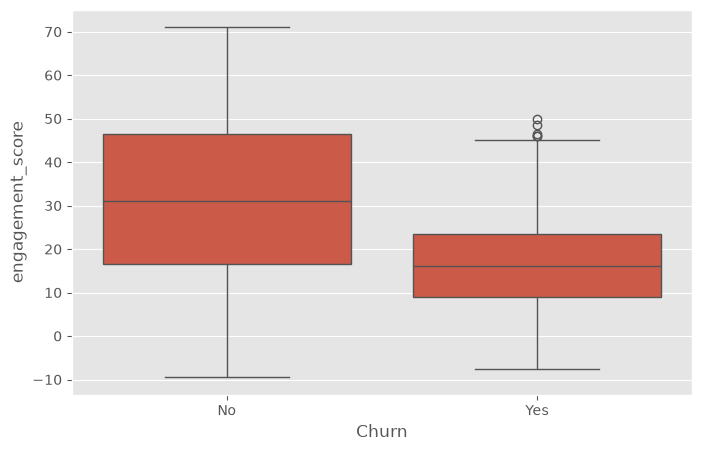

In [32]:
#engagement score
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="engagement_score"
)

plt.show()

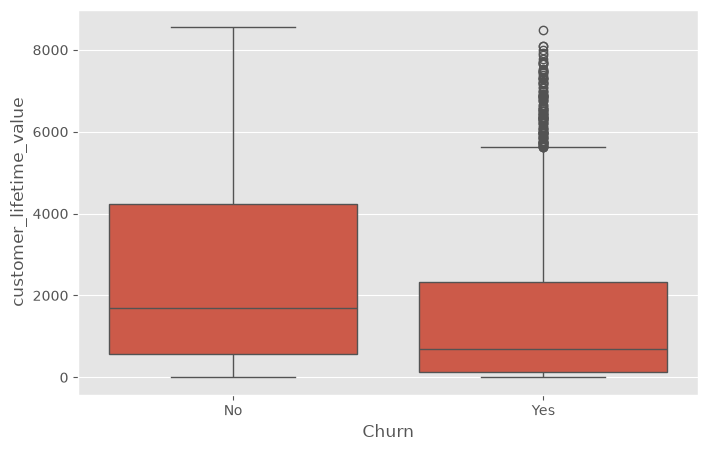

In [33]:
#customer lifetime value
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="customer_lifetime_value"
)

plt.show()

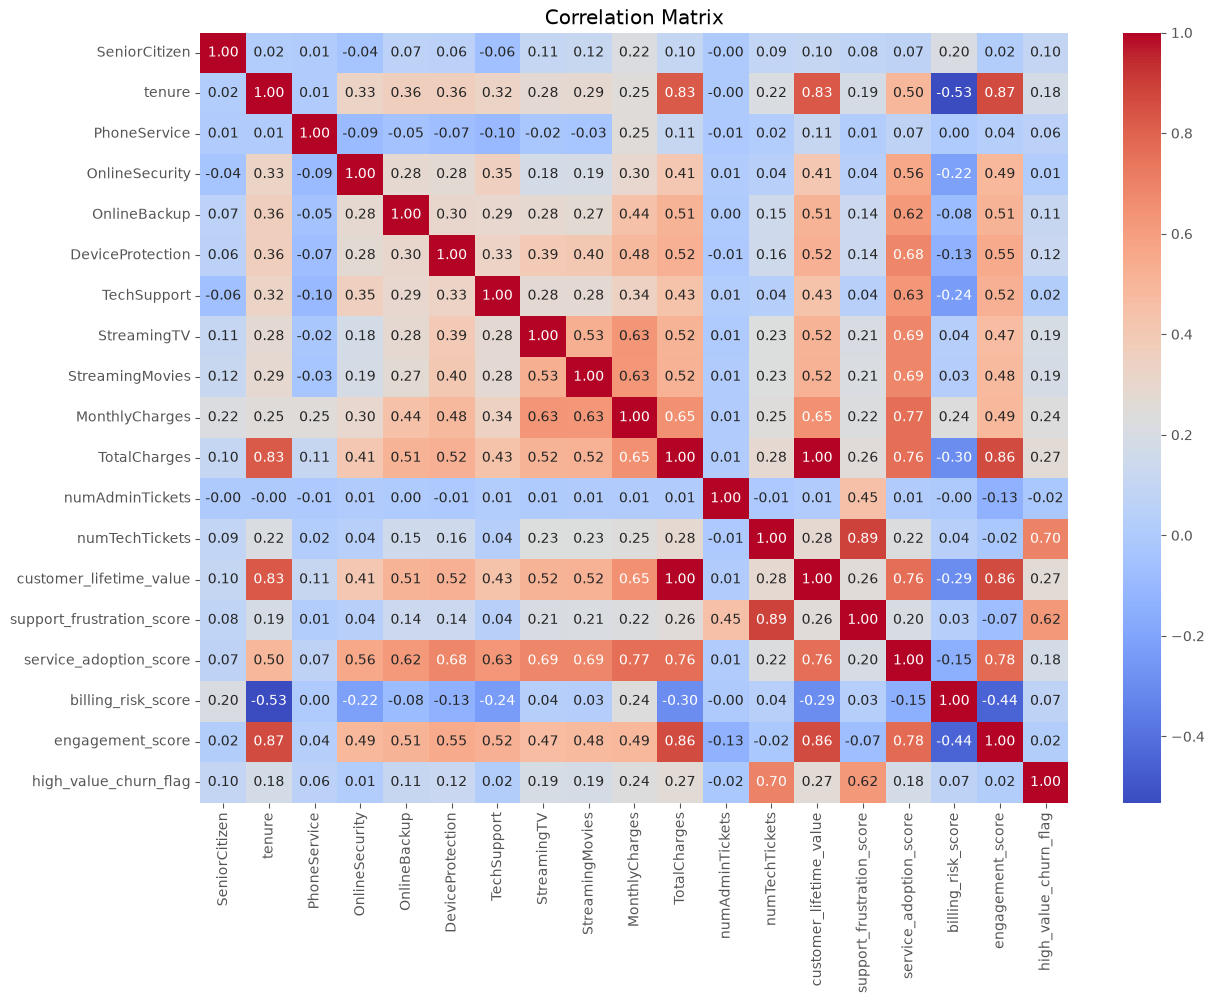

In [34]:
#corelation matrix
numeric_df = df.select_dtypes(
    include=np.number
)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

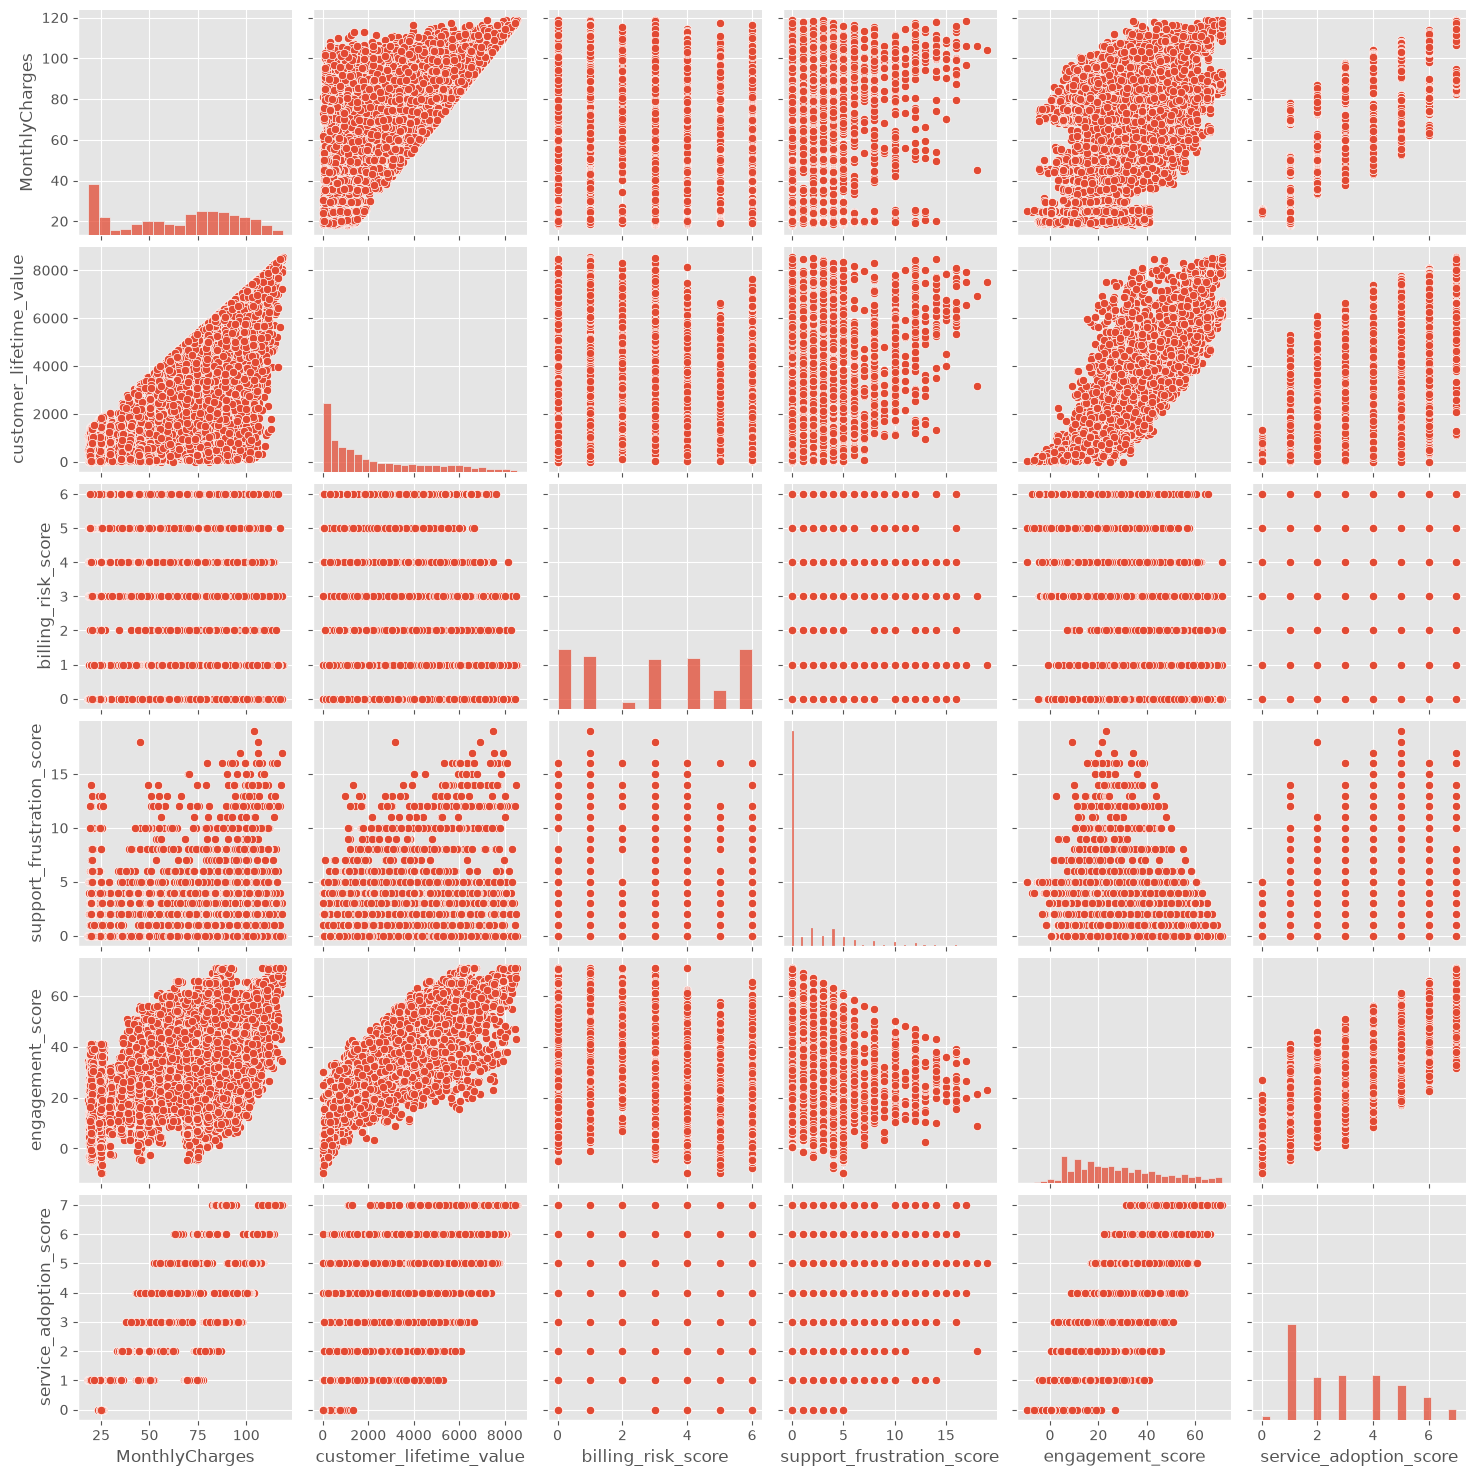

In [35]:
features = [
    "MonthlyCharges",
    "customer_lifetime_value",
    "billing_risk_score",
    "support_frustration_score",
    "engagement_score",
    "service_adoption_score"
]

sns.pairplot(
    df[features]
)

plt.show()

In [36]:
#reveneu tier vs risk segment
pivot = pd.crosstab(
    df["revenue_tier"],
    df["churn_risk_segment"]
)

pivot

churn_risk_segment,High Risk,Low Risk,Medium Risk
revenue_tier,,,
Bronze,334,1105,1468
Gold,483,1241,478
Silver,394,856,684


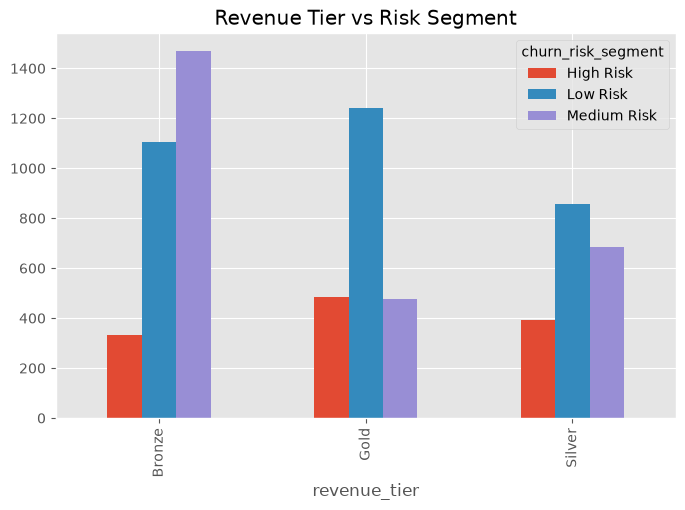

In [37]:
pivot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue Tier vs Risk Segment")

plt.show()

In [38]:
#high value customers
gold = df[
    df["revenue_tier"]=="Gold"
]

gold["Churn"].value_counts()

Churn
No     1857
Yes     345
Name: count, dtype: int64

In [39]:
#high risk cutomers
high = df[
    df["churn_risk_segment"]=="High Risk"
]

high.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn,customer_lifetime_value,revenue_tier,support_frustration_score,service_adoption_score,billing_risk_score,engagement_score,high_value_churn_flag,churn_risk_segment
8,7892-POOKP,Female,0,Yes,No,28,1,Yes,Fiber optic,0,0,1,1,1,1,Month-to-month,Yes,Electronic check,104.80,3046.05,0,2,Yes,2934.40,Silver,4,5,6,31.0,0,High Risk
13,0280-XJGEX,Male,0,No,No,49,1,Yes,Fiber optic,0,1,1,0,1,1,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,5,4,Yes,5081.30,Gold,13,5,4,23.5,1,High Risk
17,9959-WOFKT,Male,0,No,Yes,71,1,Yes,Fiber optic,1,0,1,0,1,1,Two year,No,Bank transfer (automatic),106.70,7382.25,0,4,No,7575.70,Gold,8,5,0,44.5,0,High Risk
22,1066-JKSGK,Male,0,No,No,1,1,No,No,0,0,0,0,0,0,Month-to-month,No,Mailed check,20.15,20.15,4,0,Yes,20.15,Bronze,4,1,3,-2.5,0,High Risk
24,6322-HRPFA,Male,0,Yes,Yes,49,1,No,DSL,1,1,0,1,0,0,Month-to-month,No,Credit card (automatic),59.60,2970.30,0,3,No,2920.40,Silver,6,4,3,32.5,0,High Risk


Executive Summary-



Key Findings

Approximately 26.5% of customers churned.

Month-to-month contracts have the highest churn.

Higher billing risk scores are associated with higher churn.

Customers with more support issues are more likely to churn.

Greater service adoption correlates with improved retention.

Although Gold-tier customers churn less frequently, losing them has a disproportionate revenue impact.



Business Recommendations

Convert month-to-month customers to annual contracts.

Target customers with high billing risk using proactive retention campaigns.

Improve technical support response times and resolution quality.

Promote adoption of additional services through onboarding and bundled offers.

Assign dedicated retention specialists to high-value customers identified as high risk.
